# Complement Naive Bayes: Multiclass Classification

## 1. Learning Goals

By the end of this notebook, you will be able to:

- **Understand how Complement Naive Bayes differs from Multinomial Naive Bayes**  
  You'll learn why ComplementNB was designed and when it outperforms standard Multinomial NB.

- **Apply ComplementNB to a multiclass text classification problem**  
  You'll classify newsgroup posts into multiple categories using TF-IDF features.

- **Compare ComplementNB against MultinomialNB on imbalanced data**  
  You'll see how ComplementNB handles class imbalance more gracefully.

- **Evaluate multiclass performance using per-class metrics and confusion matrices**  
  You'll go beyond accuracy to understand where each model succeeds and fails.

## 2. Why Complement Naive Bayes?

Standard Multinomial Naive Bayes estimates parameters using data from each class independently. This can lead to biased estimates, especially when:

- **Classes are imbalanced** — the model tends to favor the majority class.
- **Feature distributions are skewed** — common in text data where some classes have more documents than others.

Complement Naive Bayes (Rennie et al., 2003) addresses this by estimating parameters using data from the *complement* of each class (i.e., all classes except the one being modeled). This produces more balanced weight estimates and often achieves better accuracy on multiclass text classification tasks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

## 3. Loading a Multiclass Text Dataset

We'll use a subset of the 20 Newsgroups dataset — a classic multiclass text classification benchmark. We select 5 categories to keep things manageable while still demonstrating genuine multiclass behavior.

In [2]:
categories = [
    'rec.sport.baseball',
    'sci.med',
    'comp.graphics',
    'talk.politics.guns',
    'soc.religion.christian',
]

newsgroups = fetch_20newsgroups(
    subset='all',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),
    random_state=42,
)

print(f'Number of documents: {len(newsgroups.data)}')
print(f'Number of classes: {len(newsgroups.target_names)}')
print(f'Classes: {newsgroups.target_names}')

Number of documents: 4864
Number of classes: 5
Classes: ['comp.graphics', 'rec.sport.baseball', 'sci.med', 'soc.religion.christian', 'talk.politics.guns']


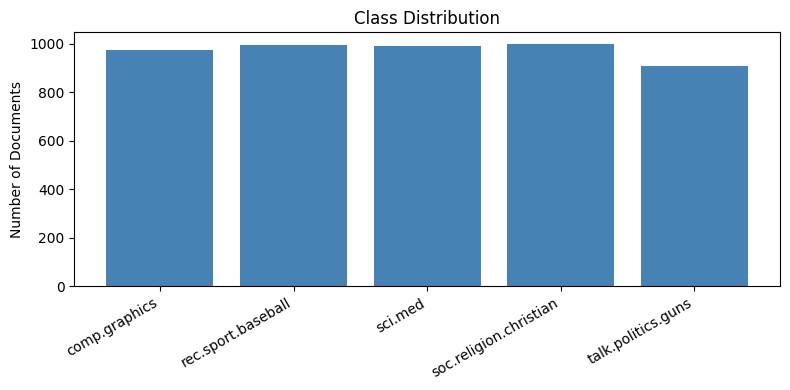

In [3]:
# Check class distribution
unique, counts = np.unique(newsgroups.target, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(newsgroups.target_names, counts, color='steelblue')
ax.set_ylabel('Number of Documents')
ax.set_title('Class Distribution')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Preprocessing with TF-IDF

We convert the raw text into TF-IDF features. TF-IDF (Term Frequency - Inverse Document Frequency) weighs words by how important they are to a document relative to the entire corpus.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    newsgroups.data, newsgroups.target,
    test_size=0.25, random_state=42, stratify=newsgroups.target
)

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f'Training set shape: {X_train_tfidf.shape}')
print(f'Test set shape: {X_test_tfidf.shape}')

Training set shape: (3648, 10000)
Test set shape: (1216, 10000)


## 5. Training ComplementNB vs MultinomialNB

Let's train both models and compare their performance on the same test set.

In [5]:
# Train MultinomialNB
mnb = MultinomialNB()
mnb.fit(X_train_tfidf, y_train)
y_pred_mnb = mnb.predict(X_test_tfidf)

# Train ComplementNB
cnb = ComplementNB()
cnb.fit(X_train_tfidf, y_train)
y_pred_cnb = cnb.predict(X_test_tfidf)

print(f'MultinomialNB accuracy: {accuracy_score(y_test, y_pred_mnb):.3f}')
print(f'ComplementNB accuracy:  {accuracy_score(y_test, y_pred_cnb):.3f}')

MultinomialNB accuracy: 0.898
ComplementNB accuracy:  0.904


## 6. Detailed Classification Reports

Accuracy alone doesn't tell the full story in multiclass problems. Let's look at precision, recall, and F1-score for each class.

In [6]:
print('=== MultinomialNB ===')
print(classification_report(y_test, y_pred_mnb, target_names=newsgroups.target_names))

print('=== ComplementNB ===')
print(classification_report(y_test, y_pred_cnb, target_names=newsgroups.target_names))

=== MultinomialNB ===
                        precision    recall  f1-score   support

         comp.graphics       0.92      0.91      0.91       243
    rec.sport.baseball       0.93      0.92      0.92       249
               sci.med       0.94      0.85      0.89       247
soc.religion.christian       0.79      0.94      0.86       249
    talk.politics.guns       0.94      0.87      0.90       228

              accuracy                           0.90      1216
             macro avg       0.90      0.90      0.90      1216
          weighted avg       0.90      0.90      0.90      1216

=== ComplementNB ===
                        precision    recall  f1-score   support

         comp.graphics       0.80      0.95      0.87       243
    rec.sport.baseball       0.95      0.92      0.93       249
               sci.med       0.95      0.85      0.90       247
soc.religion.christian       0.90      0.91      0.90       249
    talk.politics.guns       0.95      0.89      0.92    

## 7. Confusion Matrices

Confusion matrices show us exactly which classes are being confused with each other.

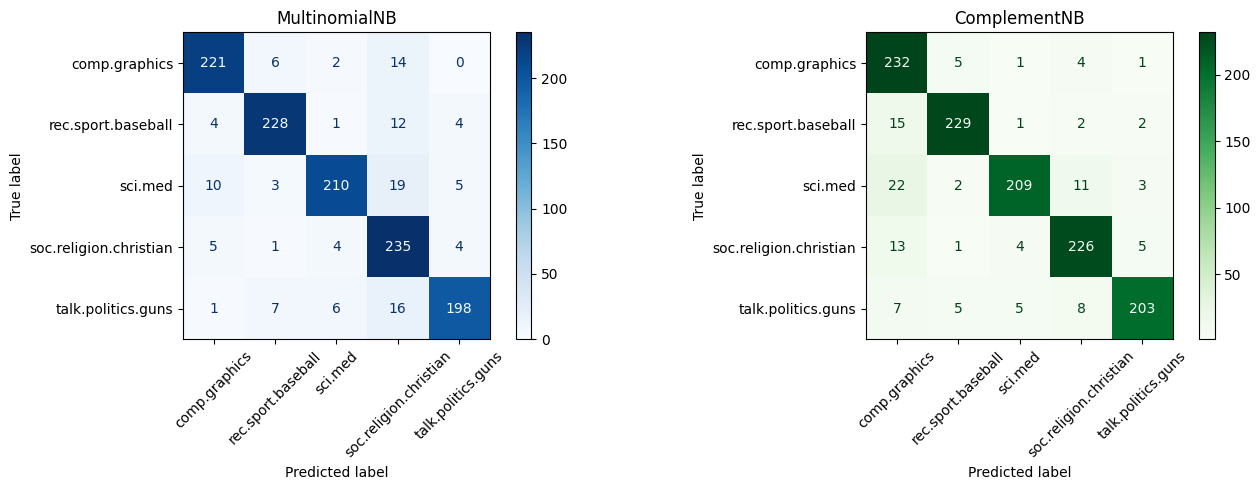

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mnb,
    display_labels=newsgroups.target_names,
    ax=axes[0], cmap='Blues', xticks_rotation=45
)
axes[0].set_title('MultinomialNB')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_cnb,
    display_labels=newsgroups.target_names,
    ax=axes[1], cmap='Greens', xticks_rotation=45
)
axes[1].set_title('ComplementNB')

plt.tight_layout()
plt.show()

## 8. Impact of Class Imbalance

To demonstrate where ComplementNB truly shines, let's artificially create class imbalance by undersampling some classes. This simulates real-world scenarios where some categories have far fewer training examples.

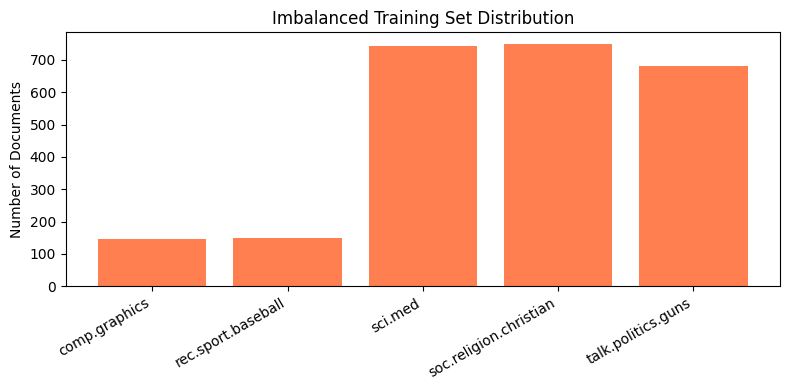

In [8]:
# Create imbalanced training set by undersampling classes 0 and 1
np.random.seed(42)
imbalanced_mask = np.ones(len(y_train), dtype=bool)

for cls in [0, 1]:
    cls_indices = np.where(y_train == cls)[0]
    drop_indices = np.random.choice(cls_indices, size=int(len(cls_indices) * 0.8), replace=False)
    imbalanced_mask[drop_indices] = False

X_train_imb = X_train_tfidf[imbalanced_mask]
y_train_imb = y_train[imbalanced_mask]

# Show new class distribution
unique_imb, counts_imb = np.unique(y_train_imb, return_counts=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(newsgroups.target_names, counts_imb, color='coral')
ax.set_ylabel('Number of Documents')
ax.set_title('Imbalanced Training Set Distribution')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# Train both models on imbalanced data
mnb_imb = MultinomialNB()
mnb_imb.fit(X_train_imb, y_train_imb)
y_pred_mnb_imb = mnb_imb.predict(X_test_tfidf)

cnb_imb = ComplementNB()
cnb_imb.fit(X_train_imb, y_train_imb)
y_pred_cnb_imb = cnb_imb.predict(X_test_tfidf)

print(f'MultinomialNB accuracy (imbalanced): {accuracy_score(y_test, y_pred_mnb_imb):.3f}')
print(f'ComplementNB accuracy (imbalanced):  {accuracy_score(y_test, y_pred_cnb_imb):.3f}')

print('\n=== MultinomialNB (imbalanced) ===')
print(classification_report(y_test, y_pred_mnb_imb, target_names=newsgroups.target_names))

print('=== ComplementNB (imbalanced) ===')
print(classification_report(y_test, y_pred_cnb_imb, target_names=newsgroups.target_names))

MultinomialNB accuracy (imbalanced): 0.570
ComplementNB accuracy (imbalanced):  0.867

=== MultinomialNB (imbalanced) ===
                        precision    recall  f1-score   support

         comp.graphics       1.00      0.07      0.12       243
    rec.sport.baseball       1.00      0.05      0.10       249
               sci.med       0.49      0.89      0.64       247
soc.religion.christian       0.63      0.96      0.76       249
    talk.politics.guns       0.57      0.90      0.69       228

              accuracy                           0.57      1216
             macro avg       0.74      0.57      0.46      1216
          weighted avg       0.74      0.57      0.46      1216

=== ComplementNB (imbalanced) ===
                        precision    recall  f1-score   support

         comp.graphics       0.83      0.83      0.83       243
    rec.sport.baseball       0.98      0.79      0.88       249
               sci.med       0.85      0.88      0.87       247
soc.reli

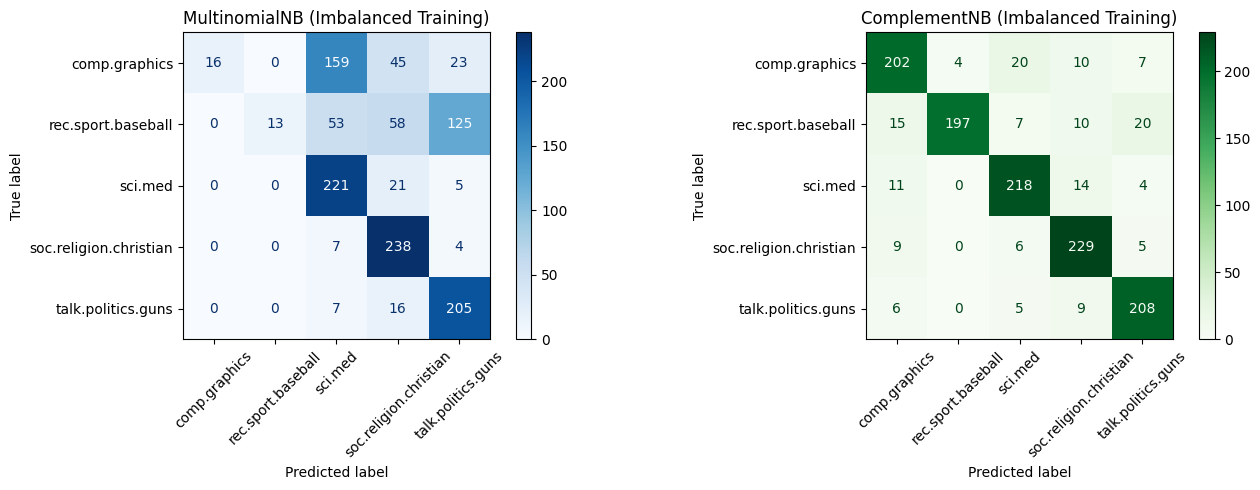

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mnb_imb,
    display_labels=newsgroups.target_names,
    ax=axes[0], cmap='Blues', xticks_rotation=45
)
axes[0].set_title('MultinomialNB (Imbalanced Training)')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_cnb_imb,
    display_labels=newsgroups.target_names,
    ax=axes[1], cmap='Greens', xticks_rotation=45
)
axes[1].set_title('ComplementNB (Imbalanced Training)')

plt.tight_layout()
plt.show()

## 9. Summary

| Aspect | MultinomialNB | ComplementNB |
|---|---|---|
| **Parameter estimation** | Uses data from each class | Uses data from the complement of each class |
| **Balanced data** | Performs well | Performs comparably or slightly better |
| **Imbalanced data** | Can be biased toward majority class | More robust, produces fairer predictions |
| **Best suited for** | Text classification with balanced classes | Text classification, especially with class imbalance |

**Key takeaway**: ComplementNB is often a better default choice than MultinomialNB for multiclass text classification. It addresses systematic biases in standard Naive Bayes estimation and is particularly effective when class sizes are unequal.